# **Customer Churn Prediction & Retention Intelligence System for an Online Fashion Store**

### **Client Description**

Sarah Ahmed is the owner of an online fashion store that has collected customer data over the past year. The business currently uses broad marketing campaigns by sending discounts to all customers, which has become costly and inefficient. Sarah wants a data-driven solution to better understand customer behavior and improve customer retention

### **Business Problem**

The company is unable to identify which customers are likely to stop purchasing from the store. As a result, marketing resources are wasted by targeting every customer instead of focusing on high-risk customers. The objective is to build an AI-driven solution that predicts at-risk customers, prioritizes them based on risk level, and helps the marketing team run targeted retention campaigns to reduce customer loss, improve marketing ROI, and increase repeat purchases.

### **Metadata**

The customers.csv dataset contains 50,000 customer records from the past 12 months, where each row represents one customer. The data includes demographics, purchase history, website activity, email engagement, and customer support interactions. Please note that the dataset has some quality issues, including missing Email_Open_Rate values, duplicate records, inconsistent location names, and a few invalid registration dates. Our goal is to use this data to identify customers who are likely to stop purchasing so we can target them efficiently and improve customer retention.

## **Bussiness Notes**

- Current retention rate: 68%
- Target: Reduce customer loss by 15%
- Marketing capacity: Target only 5,000 customers per month
- Deadline: 8 weeks
- Budget: $15,000

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [263]:
# importing the data
df = pd.read_csv("customers.csv")

In [264]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               50000 non-null  object 
 1   Name                      50000 non-null  object 
 2   Age                       50000 non-null  int64  
 3   Gender                    50000 non-null  object 
 4   Location                  50000 non-null  object 
 5   Registration_Date         50000 non-null  object 
 6   Last_Purchase_Date        45593 non-null  object 
 7   Purchase_Frequency        50000 non-null  int64  
 8   Total_Spending            50000 non-null  float64
 9   Average_Order_Value       50000 non-null  float64
 10  Website_Visits            50000 non-null  int64  
 11  Email_Open_Rate           45405 non-null  float64
 12  Customer_Support_Tickets  50000 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 5.0+ MB


In [265]:
df.head()

,Customer_ID,Name,Age,Gender,Location,Registration_Date,Last_Purchase_Date,Purchase_Frequency,Total_Spending,Average_Order_Value,Website_Visits,Email_Open_Rate,Customer_Support_Tickets
0,CUST-000001,Ayesha Awan,30,Female,NY,2025-12-30,2026-06-07,17,450.98,25.76,105,58.35,0
1,CUST-000002,Komal Shah,30,Female,Karachi,2026-06-04,2026-04-21,6,266.28,47.35,60,NaN,2
2,CUST-000003,Fatima Iqbal,23,Female,LA,2025-06-25,2026-03-21,4,122.22,34.59,16,26.06,3
3,CUST-000004,Mariam Malik,27,Female,Lahore,2026-04-14,2026-05-27,16,692.32,39.21,63,NaN,0
4,CUST-000005,Taha Siddiqui,32,Male,Islamabad,2026-01-21,NaN,0,0.00,0.00,0,25.88,1


In [266]:
df.describe()

,Age,Purchase_Frequency,Total_Spending,Average_Order_Value,Website_Visits,Email_Open_Rate,Customer_Support_Tickets
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,45405.000000,50000.000000
mean,30.70220,5.573160,381.011238,61.336408,37.243920,32.833796,1.726860
std,7.63713,5.171868,469.274498,42.105176,32.731793,21.980192,1.786762
min,18.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.00000,2.000000,83.860000,34.980000,11.000000,15.160000,0.000000
50%,30.00000,4.000000,222.080000,54.305000,28.000000,30.960000,1.000000
75%,36.00000,8.000000,503.425000,80.570000,56.000000,48.250000,3.000000
max,63.00000,32.000000,7296.900000,420.000000,193.000000,98.000000,13.000000


In [267]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Registration_Date',
       'Last_Purchase_Date', 'Purchase_Frequency', 'Total_Spending',
       'Average_Order_Value', 'Website_Visits', 'Email_Open_Rate',
       'Customer_Support_Tickets'],
      dtype='object')

#### **Working on Each Column (if Needed)**

##### **Customer_ID**

Customer_ID is a unique identifier and will not be used as a predictive feature. EDA will be limited to data quality checks such as missing values, duplicate records, uniqueness validation, and format consistency. The column will be excluded from model training but retained for customer tracking and final reporting.

In [268]:
df['Customer_ID']

0        CUST-000001
1        CUST-000002
2        CUST-000003
3        CUST-000004
4        CUST-000005
            ...     
49995    CUST-049996
49996    CUST-049997
49997    CUST-049998
49998    CUST-049999
49999    CUST-050000
Name: Customer_ID, Length: 50000, dtype: object

In [269]:
df['Customer_ID'].isnull().sum()

np.int64(0)

In [270]:
df['Customer_ID'].nunique()

49584

In [271]:
df['Customer_ID'].duplicated().sum()

np.int64(416)

In [272]:
df['Customer_ID'].duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Name: Customer_ID, Length: 50000, dtype: bool

In [273]:
df.groupby('Customer_ID')[['Total_Spending','Purchase_Frequency','Customer_Support_Tickets']].nunique()

,Total_Spending,Purchase_Frequency,Customer_Support_Tickets
Customer_ID,,,
CUST-000001,1,1,1
CUST-000002,1,1,1
CUST-000003,1,1,1
CUST-000004,1,1,1
CUST-000005,1,1,1
...,...,...,...
CUST-049996,1,1,1
CUST-049997,1,1,1
CUST-049998,1,1,1


In [274]:
df["Customer_ID"].value_counts()

Customer_ID
CUST-011068    3
CUST-005338    3
CUST-000568    3
CUST-000225    3
CUST-000696    2
              ..
CUST-049996    1
CUST-049997    1
CUST-049998    1
CUST-049999    1
CUST-050000    1
Name: count, Length: 49584, dtype: int64

In [275]:
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])
df = df.sort_values('Last_Purchase_Date').drop_duplicates('Customer_ID', keep='last')

In [276]:
#Check if all IDs are valid

pattern = r"^CUST-\d{6}$"

valid_ids = df["Customer_ID"].str.match(pattern)

print(valid_ids)


34286    True
39793    True
6670     True
10451    True
46709    True
         ... 
49952    True
49958    True
49964    True
49966    True
49998    True
Name: Customer_ID, Length: 49584, dtype: bool


In [277]:
df['Customer_ID'].duplicated().sum()

np.int64(0)

In [278]:
valid_ids.value_counts()

Customer_ID
True    49584
Name: count, dtype: int64

***Customer_ID Analysis – Conclusion***

The `Customer_ID` column does not contain any missing values, and all IDs follow a valid format. However, we identified **416 duplicate customer records**, indicating data quality issues likely caused by previous system migrations. Since `Customer_ID` is only used to identify customers and does not describe customer behavior, it will **not be used for prediction**. Duplicate records will be cleaned, and the column will be retained only for reporting and marketing purposes.

### **Name Column**

In [279]:
df['Name']

34286    Fahad Siddiqui
39793      Komal Sheikh
6670         Rabia Raza
10451     Sarah Hussain
46709        Anum Mirza
              ...      
49952    Imran Siddiqui
49958      Zara Hussain
49964     Ayesha Ansari
49966         Zara Shah
49998     Farhan Ansari
Name: Name, Length: 49584, dtype: object

In [280]:
df['Name'].isnull().sum()

np.int64(0)

In [281]:
df['Name'].duplicated().sum()

np.int64(49134)

In [282]:
df['Name'].value_counts()

Name
Rabia Malik        185
Zara Shah          181
Sana Malik         177
Fatima Siddiqui    175
Laiba Ahmed        174
                  ... 
Danish Ahmed        53
Zain Sheikh         52
Fahad Khan          52
Danish Ansari       51
Bilal Raza          49
Name: count, Length: 450, dtype: int64

In [283]:
df['Name'].nunique()

450

In [284]:
df['Name'].str.contains(r'[^a-zA-Z\s]').sum()

np.int64(0)

In [285]:
#Empty or invalid names
df[df['Name'].str.strip() == '']

,Customer_ID,Name,Age,Gender,Location,Registration_Date,Last_Purchase_Date,Purchase_Frequency,Total_Spending,Average_Order_Value,Website_Visits,Email_Open_Rate,Customer_Support_Tickets




 ***Conclusion***
 
The `Name` column serves only as a customer identifier and does not provide meaningful information about customer purchasing behavior. Basic data quality checks is performed to identify missing or invalid entries, but the column will be excluded from model training. It may be retained for reporting purposes only if required by the marketing team.

### **Age Column**

In [286]:
df['Age']

34286    38
39793    30
6670     26
10451    27
46709    20
         ..
49952    20
49958    33
49964    38
49966    23
49998    18
Name: Age, Length: 49584, dtype: int64

In [287]:
df['Age'].isnull().sum()

np.int64(0)

In [288]:
df['Age'].duplicated().sum()

np.int64(49538)

In [289]:
df['Age'].describe()

count    49584.000000
mean        30.705147
std          7.634829
min         18.000000
25%         25.000000
50%         30.000000
75%         36.000000
max         63.000000
Name: Age, dtype: float64

In [290]:
df['Age'].nunique()

46

In [291]:
df['Age'].unique()

array([38, 30, 26, 27, 20, 34, 35, 18, 29, 31, 44, 25, 22, 24, 36, 33, 46,
       40, 48, 23, 43, 32, 21, 37, 45, 19, 41, 28, 39, 42, 52, 53, 47, 49,
       54, 50, 51, 63, 56, 55, 59, 57, 61, 60, 58, 62])

In [292]:
df['Age'].value_counts()

Age
18    3356
30    2531
29    2425
32    2413
31    2357
34    2305
33    2305
28    2281
27    2223
26    2157
35    2142
36    2024
25    1985
24    1787
37    1752
23    1578
38    1543
22    1422
39    1359
40    1227
21    1223
41    1062
20    1036
19     870
42     865
43     684
44     645
45     478
46     362
47     290
48     248
49     178
50     140
51      85
52      75
53      52
54      36
55      27
56      22
57      11
59       9
60       7
58       3
63       2
61       1
62       1
Name: count, dtype: int64

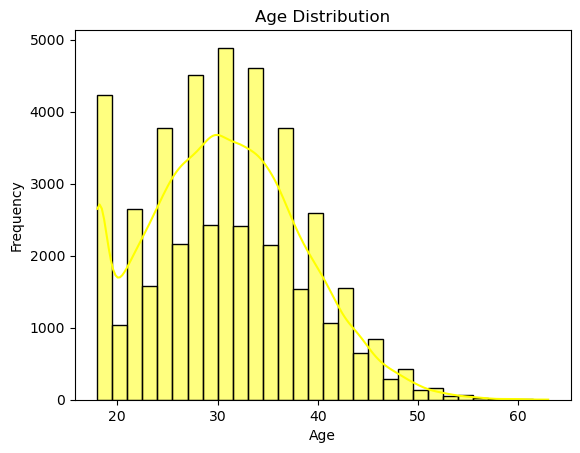

In [293]:
# Age Distribution
sns.histplot(df['Age'], kde=True, bins=30, color='yellow' )
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


In [294]:
df['Age'].skew()

np.float64(0.283044675517758)

<Axes: xlabel='Age'>

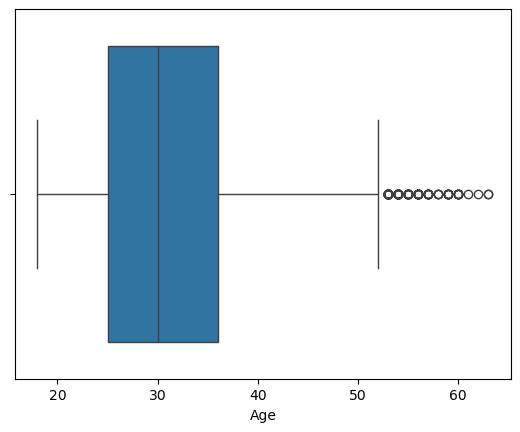

In [295]:
# Age outlier check
sns.boxplot(x=df['Age'])

In [296]:
# Removing the Outliers
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]



<Axes: xlabel='Age'>

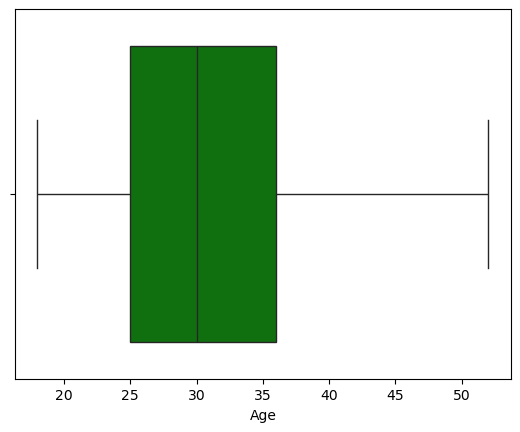

In [297]:
# Age outlier check
sns.boxplot(x=df['Age'],color='green')

In [298]:
# Creating Age Groups
bins = [0, 18, 30, 45, 60]
labels = ['0-18', '19-30', '31-45', '46-60']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)


In [299]:
df['Age_Group']

34286    31-45
39793    19-30
6670     19-30
10451    19-30
46709    19-30
         ...  
49952    19-30
49958    31-45
49964    31-45
49966    19-30
49998     0-18
Name: Age_Group, Length: 49413, dtype: category
Categories (4, object): ['0-18' < '19-30' < '31-45' < '46-60']

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\3991855881.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Purchase_Frequency'].mean().plot(kind='bar', color='red', edgecolor='black')


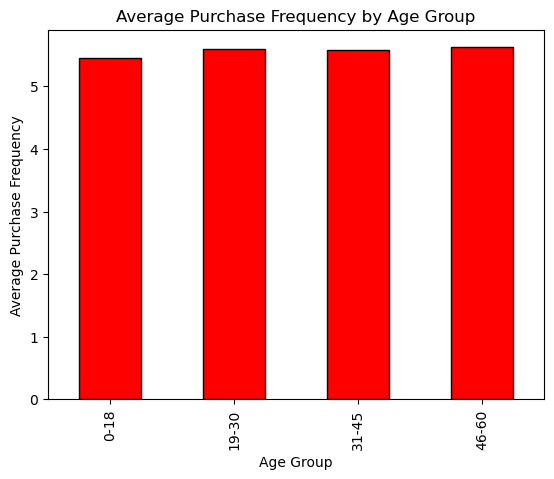

In [300]:
# Which age group purchases more frequently?
df.groupby('Age_Group')['Purchase_Frequency'].mean().plot(kind='bar', color='red', edgecolor='black')
plt.title('Average Purchase Frequency by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Purchase Frequency')
plt.show()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\4042513483.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Total_Spending'].mean().plot(kind='bar', color='blue', edgecolor='black')


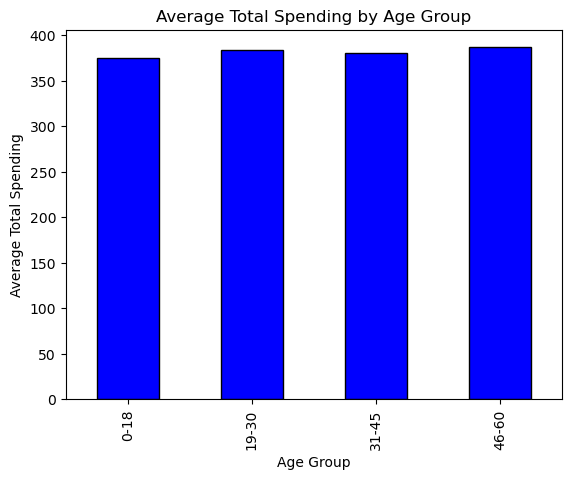

In [301]:
# Which age group spends more?
df.groupby('Age_Group')['Total_Spending'].mean().plot(kind='bar', color='blue', edgecolor='black')
plt.title('Average Total Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Total Spending')
plt.show()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2967707571.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Customer_Support_Tickets'].mean().plot(kind='bar', color='orange', edgecolor='black')


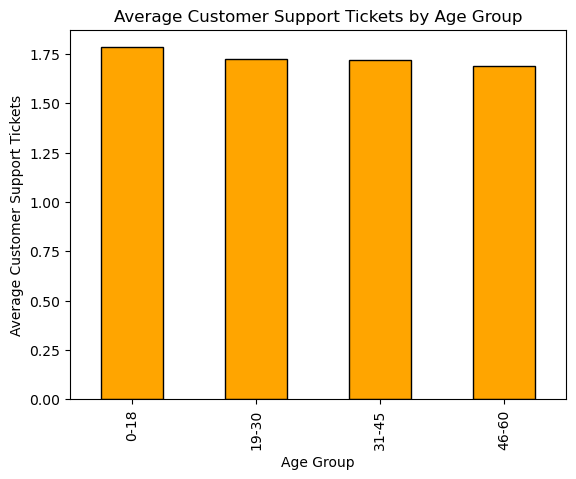

In [302]:
# Which age group appears less engaged?
df.groupby('Age_Group')['Customer_Support_Tickets'].mean().plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average Customer Support Tickets by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Customer Support Tickets')
plt.show()


 ***Age Analysis – Findings & Conclusion***

The `Age` column contains **49,584 valid records with no missing values**, and customer ages range from **18 to 63 years**, with an average age of **31 years**. Most customers belong to the **25–36 age group**, indicating that young adults are the store's primary customer segment. Purchase frequency, total spending, and customer support interactions are relatively similar across all age groups, suggesting that **age alone may not be a strong indicator of customer churn**. Therefore, `Age` will be retained as a supporting feature in the model and further evaluated alongside behavioral features such as purchase history and customer engagement.

### **Gender Column**

In [303]:
df['Gender']

34286      Male
39793    Female
6670     Female
10451    Female
46709    Female
          ...  
49952      Male
49958    Female
49964    Female
49966    Female
49998      Male
Name: Gender, Length: 49413, dtype: object

In [304]:
df['Gender'].value_counts()

Gender
Female    33883
Male      15530
Name: count, dtype: int64

In [305]:
df['Gender'].isnull().sum()

np.int64(0)

<Axes: xlabel='Gender'>

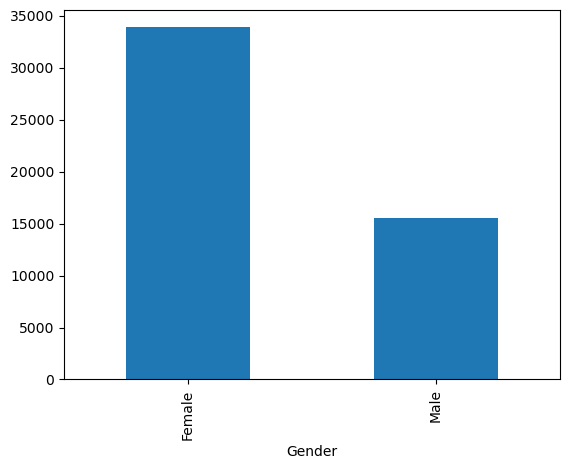

In [306]:
df['Gender'].value_counts().plot(kind='bar')

In [307]:
df.groupby('Gender')['Purchase_Frequency'].mean()

Gender
Female    5.594694
Male      5.546555
Name: Purchase_Frequency, dtype: float64

In [308]:
df.groupby('Gender')['Total_Spending'].mean()

Gender
Female    382.693776
Male      378.416475
Name: Total_Spending, dtype: float64

In [309]:
df.groupby('Gender')['Website_Visits'].mean()

Gender
Female    37.404923
Male      37.050676
Name: Website_Visits, dtype: float64

In [310]:
df.groupby('Gender')['Email_Open_Rate'].mean()

Gender
Female    32.921425
Male      32.718719
Name: Email_Open_Rate, dtype: float64

In [311]:
df.groupby('Gender')['Customer_Support_Tickets'].mean()

Gender
Female    1.721247
Male      1.734514
Name: Customer_Support_Tickets, dtype: float64

***Gender Analysis – Findings & Conclusion***

The `Gender` column contains **no missing values**, and the dataset is composed of **33,883 female customers (69%)** and **15,530 male customers (31%)**. The analysis shows that both genders exhibit **very similar purchasing and engagement behaviors**, with only minor differences in purchase frequency, website visits, email open rates, and customer support interactions. These differences are too small to indicate a meaningful impact on customer churn when considered independently. Therefore, `Gender` will be retained as a **supporting feature** but is **unlikely to be a strong predictor of churn** and should be used in combination with behavioral features.

***Business Question Answer***

**Do customers of different genders show different purchasing or engagement behavior that could help identify churn risk?**

**No.** Based on the analysis, customers of different genders display very similar purchasing and engagement patterns. Gender alone does not appear to provide strong evidence for identifying customers who are likely to stop purchasing, so it is not expected to be a key driver of churn prediction.

### **Location Column**

In [312]:
df['Location']

34286     Rawalpindi
39793     Rawalpindi
6670          Multan
10451         Quetta
46709    Los Angeles
            ...     
49952    Los Angeles
49958    Los Angeles
49964     Rawalpindi
49966       Peshawar
49998       New York
Name: Location, Length: 49413, dtype: object

In [313]:
df['Location'].value_counts()

Location
Karachi        10949
Lahore          6870
Islamabad       4861
Rawalpindi      3951
Faisalabad      2960
Dubai           2414
Multan          2013
London          1994
Peshawar        1974
New York        1560
Quetta          1498
NY              1484
Los Angeles     1467
Toronto         1447
Mississauga     1008
LA               994
Manchester       986
UAE-Dubai        498
NewYork          485
Name: count, dtype: int64

In [314]:
df['Location'].nunique()

19

In [315]:
df['Location'] = df['Location'].str.lower().str.strip()

In [316]:
Location_mapping = {
    'ny': 'new york',
    'newyork': 'new york',
    'la': 'los angeles',
    'uae-dubai': 'dubai'
}

df['Location'] = df['Location'].replace(Location_mapping)

In [317]:
df['Location'].value_counts()

Location
karachi        10949
lahore          6870
islamabad       4861
rawalpindi      3951
new york        3529
faisalabad      2960
dubai           2912
los angeles     2461
multan          2013
london          1994
peshawar        1974
quetta          1498
toronto         1447
mississauga     1008
manchester       986
Name: count, dtype: int64

In [318]:
df['Location'].nunique()

15

In [319]:
df['Location'].isnull().sum()

np.int64(0)

In [320]:
df['Location'] = df['Location'].str.replace(r'\s+', ' ', regex=True)

<Axes: xlabel='Location'>

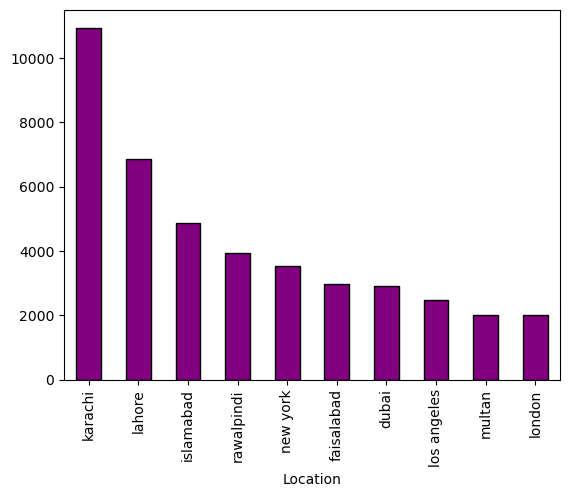

In [321]:
df['Location'].value_counts().head(10).plot(kind='bar', color='purple', edgecolor='black')

In [322]:
df.groupby('Location')['Purchase_Frequency'].mean()

Location
dubai          5.574863
faisalabad     5.515203
islamabad      5.689776
karachi        5.545986
lahore         5.588501
london         5.567202
los angeles    5.458350
manchester     5.628803
mississauga    5.675595
multan         5.531545
new york       5.569566
peshawar       5.533941
quetta         5.606142
rawalpindi     5.668945
toronto        5.566690
Name: Purchase_Frequency, dtype: float64

In [323]:
df.groupby('Location')['Total_Spending'].mean()

Location
dubai          384.019179
faisalabad     380.144145
islamabad      384.300446
karachi        379.310882
lahore         384.901888
london         368.444574
los angeles    377.432202
manchester     379.920568
mississauga    396.675456
multan         380.615400
new york       384.297138
peshawar       371.650760
quetta         378.571302
rawalpindi     386.393743
toronto        377.997305
Name: Total_Spending, dtype: float64

In [324]:
df.groupby('Location')['Website_Visits'].mean()

Location
dubai          36.533997
faisalabad     36.860811
islamabad      38.198519
karachi        37.133620
lahore         37.198836
london         37.042126
los angeles    36.156440
manchester     37.416836
mississauga    37.779762
multan         37.299553
new york       36.840465
peshawar       37.400709
quetta         38.306409
rawalpindi     38.247026
toronto        37.484451
Name: Website_Visits, dtype: float64

In [325]:
df.groupby('Location')['Email_Open_Rate'].mean()

Location
dubai          32.642552
faisalabad     32.624786
islamabad      32.855547
karachi        32.878053
lahore         33.306732
london         32.523729
los angeles    32.571550
manchester     33.245617
mississauga    32.473436
multan         32.161841
new york       33.114519
peshawar       32.496917
quetta         33.037304
rawalpindi     32.944550
toronto        32.850288
Name: Email_Open_Rate, dtype: float64

In [326]:
df.groupby('Location')['Customer_Support_Tickets'].mean()

Location
dubai          1.735577
faisalabad     1.727703
islamabad      1.706439
karachi        1.740707
lahore         1.694760
london         1.747242
los angeles    1.718001
manchester     1.620690
mississauga    1.781746
multan         1.760060
new york       1.728252
peshawar       1.728977
quetta         1.751001
rawalpindi     1.744369
toronto        1.670352
Name: Customer_Support_Tickets, dtype: float64

***Location Analysis – Findings & Conclusion***

The `Location` column contains **19 unique locations** with **no missing values**, and most customers are concentrated in **Karachi, Lahore, and Islamabad**. The analysis shows only minor differences in purchase frequency, spending, website visits, and email engagement across locations. Therefore, **location alone is not a strong indicator of customer churn**, but it may provide additional context when combined with behavioral features. This column will be retained as a **supporting feature** for the prediction model.

***Key Business Insights***

- **Karachi, Lahore, and Islamabad** represent the largest customer segments and may be prioritized for retention campaigns due to their customer volume.
- **Mississauga** shows the highest average spending, indicating a potentially high-value customer segment.
- **Rawalpindi, Quetta, and Islamabad** have slightly higher website engagement levels.
- Overall, **behavioral features are expected to be much stronger churn predictors than geographical location.**

### **Registration Date Column**

In [327]:
df['Registration_Date']

34286    2026-06-07
39793    2026-04-02
6670     2025-07-19
10451    2024-09-04
46709    2024-10-17
            ...    
49952    2026-03-29
49958    2025-11-14
49964    2025-07-11
49966    2024-09-29
49998    2025-12-10
Name: Registration_Date, Length: 49413, dtype: object

In [328]:
df['Registration_Date'] = pd.to_datetime(df['Registration_Date'])

In [329]:
df['Registration_Date'].isnull().sum()

np.int64(0)

In [330]:
df['Customer_Tenure_Days'] = (
    pd.Timestamp.today() - df['Registration_Date']
).dt.days

In [331]:
df['Customer_Tenure_Days']

34286     17
39793     83
6670     340
10451    658
46709    615
        ... 
49952     87
49958    222
49964    348
49966    633
49998    196
Name: Customer_Tenure_Days, Length: 49413, dtype: int64

In [332]:
df['Registration_Date'] = pd.to_datetime(df['Registration_Date'], errors='coerce')
today = pd.Timestamp.today()

invalid_reg_mask = (
    df['Registration_Date'].isna() |
    (df['Registration_Date'] > today)
)

df['Customer_Tenure_Days'] = np.nan

df.loc[~invalid_reg_mask, 'Customer_Tenure_Days'] = (
    today - df.loc[~invalid_reg_mask, 'Registration_Date']
).dt.days

print(f"Excluded {invalid_reg_mask.sum()} rows from tenure calculations.")

Excluded 301 rows from tenure calculations.


In [333]:
df['Customer_Tenure_Days'].describe()

count    49112.000000
mean       369.941399
std        209.773209
min          0.000000
25%        188.000000
50%        369.000000
75%        552.000000
max        734.000000
Name: Customer_Tenure_Days, dtype: float64

<Axes: >

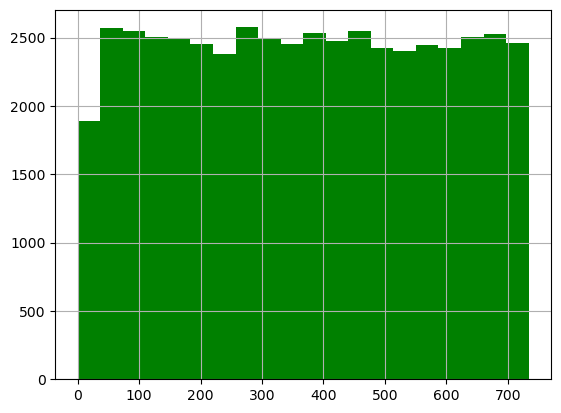

In [334]:
df['Customer_Tenure_Days'].hist(bins=20, color='green')

In [335]:
df.groupby(pd.cut(
    df['Customer_Tenure_Days'],
    bins=[0,90,180,365,730]
))['Purchase_Frequency'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\3289600619.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(


Customer_Tenure_Days
(0, 90]       5.421652
(90, 180]     5.624899
(180, 365]    5.624790
(365, 730]    5.595473
Name: Purchase_Frequency, dtype: float64

In [336]:
df.groupby(pd.cut(
    df['Customer_Tenure_Days'],
    bins=[0,90,180,365,730]
))['Total_Spending'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\608579078.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(


Customer_Tenure_Days
(0, 90]       373.603771
(90, 180]     384.380568
(180, 365]    385.309900
(365, 730]    381.407416
Name: Total_Spending, dtype: float64

In [337]:
df.groupby(pd.cut(
    df['Customer_Tenure_Days'],
    bins=[0,90,180,365,730]
))['Email_Open_Rate'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2385995884.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(


Customer_Tenure_Days
(0, 90]       32.721381
(90, 180]     32.891008
(180, 365]    32.945284
(365, 730]    32.890100
Name: Email_Open_Rate, dtype: float64

In [338]:
df.groupby(pd.cut(
    df['Customer_Tenure_Days'],
    bins=[0,90,180,365,730]
))['Customer_Support_Tickets'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\557843314.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(


Customer_Tenure_Days
(0, 90]       1.771546
(90, 180]     1.742412
(180, 365]    1.714057
(365, 730]    1.717694
Name: Customer_Support_Tickets, dtype: float64

In [339]:
df.groupby(pd.cut(
    df['Customer_Tenure_Days'],
    bins=[0,90,180,365,730]
))['Website_Visits'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\3804579978.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(


Customer_Tenure_Days
(0, 90]       36.910078
(90, 180]     37.456095
(180, 365]    37.466155
(365, 730]    37.377901
Name: Website_Visits, dtype: float64

***Registration Date (Customer Tenure) – Findings & Conclusion***

A total of **310 records with invalid future registration dates were excluded** from tenure calculations. The analysis shows that customers with a longer tenure (180–365 days) have slightly higher purchase frequency, spending, and website engagement compared to newer customers (0–90 days). However, the differences are relatively small, suggesting that **customer tenure alone is not a strong indicator of churn**, but it may provide useful context when combined with behavioral features. Therefore, `Customer_Tenure_Days` will be retained as a supporting feature in the prediction model.

***Business Question Answer***

**Does customer tenure influence their likelihood of stopping purchases?**

**Partially.** Newer customers (0–90 days) show slightly lower purchase frequency and spending, while longer-tenure customers appear marginally more engaged and valuable. Although tenure is not a strong standalone predictor of churn, it can help improve predictions when used alongside behavioral features such as purchase history and customer engagement.

In [340]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Registration_Date',
       'Last_Purchase_Date', 'Purchase_Frequency', 'Total_Spending',
       'Average_Order_Value', 'Website_Visits', 'Email_Open_Rate',
       'Customer_Support_Tickets', 'Age_Group', 'Customer_Tenure_Days'],
      dtype='object')

### **Last Purchase Date Column**

In [341]:
df['Last_Purchase_Date']

34286   2025-06-20
39793   2025-06-20
6670    2025-06-20
10451   2025-06-20
46709   2025-06-20
           ...    
49952          NaT
49958          NaT
49964          NaT
49966          NaT
49998          NaT
Name: Last_Purchase_Date, Length: 49413, dtype: datetime64[ns]

In [342]:
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

In [343]:
df['Last_Purchase_Date'].isnull().sum()

np.int64(4389)

In [344]:
df['Never_Purchased'] = df['Last_Purchase_Date'].isna().astype(int)

In [345]:
df['Days_Since_Last_Purchase'] = (
    pd.Timestamp.today() - df['Last_Purchase_Date']
).dt.days

df['Days_Since_Last_Purchase'] = df['Days_Since_Last_Purchase'].fillna(-1)

In [346]:
df['Days_Since_Last_Purchase']

34286    369.0
39793    369.0
6670     369.0
10451    369.0
46709    369.0
         ...  
49952     -1.0
49958     -1.0
49964     -1.0
49966     -1.0
49998     -1.0
Name: Days_Since_Last_Purchase, Length: 49413, dtype: float64

In [347]:
df['Days_Since_Last_Purchase'].describe()

count    49413.000000
mean        68.172424
std         67.839486
min         -1.000000
25%         16.000000
50%         46.000000
75%        103.000000
max        369.000000
Name: Days_Since_Last_Purchase, dtype: float64

<Axes: >

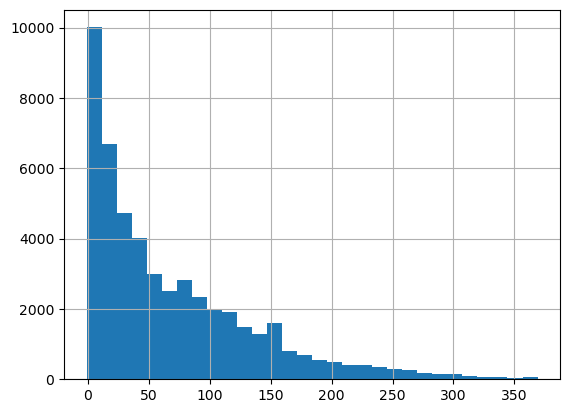

In [348]:
df['Days_Since_Last_Purchase'].hist(bins=30)

In [349]:
df['Purchase_Recency_Group'] = pd.cut(
    df['Days_Since_Last_Purchase'],
    bins=[0,30,60,90,180,365],
    labels=[
        'Very Active',
        'Active',
        'At Risk',
        'High Risk',
        'Inactive'
    ]
)

<Axes: xlabel='Purchase_Recency_Group'>

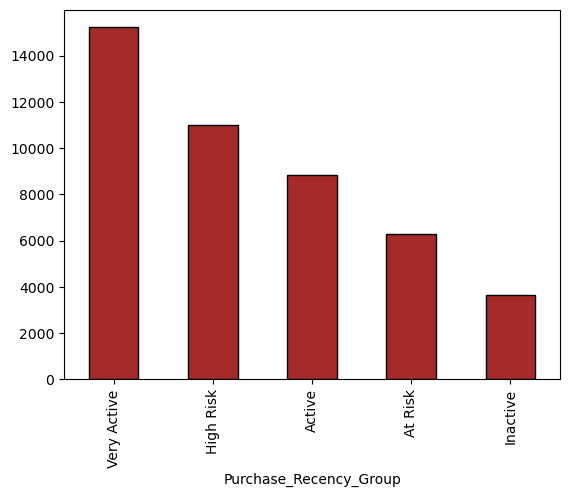

In [350]:
df['Purchase_Recency_Group'].value_counts().plot(kind='bar', color='brown', edgecolor='black')

In [351]:
df.groupby('Purchase_Recency_Group')['Purchase_Frequency'].mean()



C:\Users\AK\AppData\Local\Temp\ipykernel_14320\4089364869.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Purchase_Recency_Group')['Purchase_Frequency'].mean()


Purchase_Recency_Group
Very Active    8.966770
Active         7.203894
At Risk        4.913313
High Risk      3.446832
Inactive       1.837298
Name: Purchase_Frequency, dtype: float64

In [352]:

df.groupby('Purchase_Recency_Group')['Total_Spending'].mean()



C:\Users\AK\AppData\Local\Temp\ipykernel_14320\1425120259.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Purchase_Recency_Group')['Total_Spending'].mean()


Purchase_Recency_Group
Very Active    612.890574
Active         493.367780
At Risk        342.062652
High Risk      231.754149
Inactive       123.989475
Name: Total_Spending, dtype: float64

In [353]:
df.groupby('Purchase_Recency_Group')['Website_Visits'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2020570519.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Purchase_Recency_Group')['Website_Visits'].mean()


Purchase_Recency_Group
Very Active    58.511985
Active         47.654591
At Risk        32.907269
High Risk      23.473962
Inactive        8.487832
Name: Website_Visits, dtype: float64

In [354]:
df.groupby('Purchase_Recency_Group')['Email_Open_Rate'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2354719939.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Purchase_Recency_Group')['Email_Open_Rate'].mean()


Purchase_Recency_Group
Very Active    43.895935
Active         38.771008
At Risk        31.260479
High Risk      25.973651
Inactive       13.560275
Name: Email_Open_Rate, dtype: float64

In [355]:
df.groupby('Purchase_Recency_Group')['Customer_Support_Tickets'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\3452533238.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Purchase_Recency_Group')['Customer_Support_Tickets'].mean()


Purchase_Recency_Group
Very Active    1.243778
Active         1.358429
At Risk        1.737077
High Risk      2.078296
Inactive       3.106371
Name: Customer_Support_Tickets, dtype: float64

***Last Purchase Date (Purchase Recency) – Findings & Conclusion***

The analysis shows a **strong relationship between purchase recency and customer engagement**. Customers who purchased recently (**Very Active**) have the highest purchase frequency, spending, website activity, and email engagement, while **Inactive** customers show a significant decline across all these metrics and generate the highest number of support tickets. This indicates that **days since the last purchase is one of the strongest indicators of customer churn**. Therefore, `Days_Since_Last_Purchase` will be retained as a **key predictive feature** in the churn prediction model.


### **Purchase Frequency**

In [356]:
df['Purchase_Frequency'].isnull().sum()

np.int64(0)

In [357]:
df['Purchase_Frequency'].describe()

count    49413.000000
mean         5.579564
std          5.177030
min          0.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         32.000000
Name: Purchase_Frequency, dtype: float64

In [358]:
(df['Purchase_Frequency'] == 0).sum()

np.int64(4389)

<Axes: >

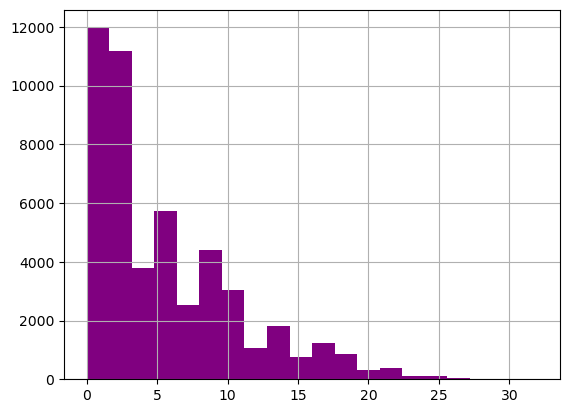

In [359]:
df['Purchase_Frequency'].hist(bins=20, color = 'Purple')

In [360]:
#checking skewness
df['Purchase_Frequency'].skew()

np.float64(1.2423847671190928)

<Axes: xlabel='Purchase_Frequency'>

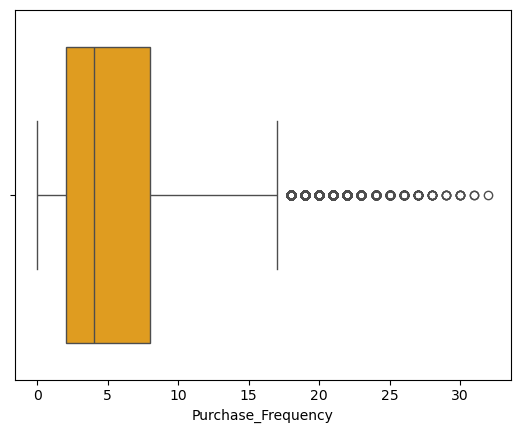

In [361]:
# checking outliers
sns.boxplot(x=df['Purchase_Frequency'], color='orange')

In [362]:
df['Purchase_Frequency'].nunique()

33

In [363]:
df['Purchase_Frequency'].value_counts()

Purchase_Frequency
1     7599
2     5956
3     5219
0     4389
4     3779
5     3122
6     2604
7     2521
8     2325
9     2080
10    1723
11    1314
12    1059
13     966
14     862
15     767
16     652
17     594
18     487
19     389
20     317
21     246
22     144
23     107
24      78
25      45
26      31
27      18
28       8
30       5
29       4
31       2
32       1
Name: count, dtype: int64

In [364]:
Q1 = df['Purchase_Frequency'].quantile(0.25)
Q3 = df['Purchase_Frequency'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [365]:
outliers = df[
    (df['Purchase_Frequency'] < lower) |
    (df['Purchase_Frequency'] > upper)
]

In [366]:
outliers

,Customer_ID,Name,Age,Gender,Location,Registration_Date,Last_Purchase_Date,Purchase_Frequency,Total_Spending,Average_Order_Value,Website_Visits,Email_Open_Rate,Customer_Support_Tickets,Age_Group,Customer_Tenure_Days,Never_Purchased,Days_Since_Last_Purchase,Purchase_Recency_Group
29542,CUST-029543,Omar Iqbal,32,Male,los angeles,2026-02-25,2026-03-22,18,768.18,41.61,68,51.09,2,31-45,119.0,0,94.0,High Risk
41900,CUST-041901,Nimra Qureshi,41,Female,dubai,2025-11-25,2026-03-22,21,448.33,23.19,69,53.60,1,31-45,211.0,0,94.0,High Risk
45880,CUST-045881,Anum Shah,33,Female,lahore,2024-07-14,2026-03-22,18,1142.96,57.63,118,75.83,2,31-45,710.0,0,94.0,High Risk
28532,CUST-028533,Saad Khan,35,Male,quetta,2024-11-22,2026-03-22,20,1118.53,49.68,82,55.09,0,31-45,579.0,0,94.0,High Risk
17222,CUST-017223,Farhan Iqbal,38,Male,dubai,2025-08-21,2026-03-22,18,986.59,56.02,92,35.68,0,31-45,307.0,0,94.0,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12137,CUST-012138,Ayesha Butt,35,Female,islamabad,2025-08-08,2026-06-20,19,2823.93,131.14,33,31.09,2,31-45,320.0,0,4.0,Very Active
28140,CUST-028141,Ali Sheikh,42,Male,karachi,2024-07-23,2026-06-20,21,2031.94,82.17,85,16.89,1,31-45,701.0,0,4.0,Very Active
38876,CUST-038877,Sana Siddiqui,37,Female,peshawar,2024-06-29,2026-06-20,18,1645.40,84.61,66,53.41,2,31-45,725.0,0,4.0,Very Active
44117,CUST-044118,Laiba Siddiqui,18,Female,rawalpindi,2024-09-14,2026-06-20,18,933.07,48.68,114,47.54,2,0-18,648.0,0,4.0,Very Active


In [367]:
df['Purchase_Segment'] = pd.cut(
    df['Purchase_Frequency'],
    bins=[-1,1,3,7,100],
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High'
    ]
)

In [368]:
df['Purchase_Segment']

34286    Very Low
39793         Low
6670          Low
10451         Low
46709    Very Low
           ...   
49952    Very Low
49958    Very Low
49964    Very Low
49966    Very Low
49998    Very Low
Name: Purchase_Segment, Length: 49413, dtype: category
Categories (4, object): ['Very Low' < 'Low' < 'Medium' < 'High']

<Axes: xlabel='Purchase_Segment'>

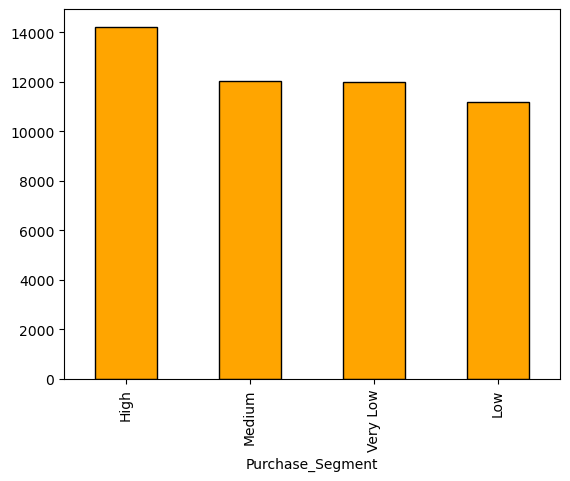

In [369]:
df['Purchase_Segment'].value_counts().plot(kind='bar', color='orange', edgecolor='black')

In [370]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Registration_Date',
       'Last_Purchase_Date', 'Purchase_Frequency', 'Total_Spending',
       'Average_Order_Value', 'Website_Visits', 'Email_Open_Rate',
       'Customer_Support_Tickets', 'Age_Group', 'Customer_Tenure_Days',
       'Never_Purchased', 'Days_Since_Last_Purchase', 'Purchase_Recency_Group',
       'Purchase_Segment'],
      dtype='object')

### ***Total Spending Column***

In [371]:
df['Total_Spending']

34286     89.32
39793     97.49
6670      90.51
10451    241.42
46709     37.53
          ...  
49952      0.00
49958      0.00
49964      0.00
49966      0.00
49998      0.00
Name: Total_Spending, Length: 49413, dtype: float64

In [372]:
df['Total_Spending'].describe()

count    49413.000000
mean       381.349464
std        468.625803
min          0.000000
25%         83.850000
50%        222.730000
75%        504.350000
max       7296.900000
Name: Total_Spending, dtype: float64

In [373]:
df['Total_Spending'].isnull().sum()

np.int64(0)

<Axes: >

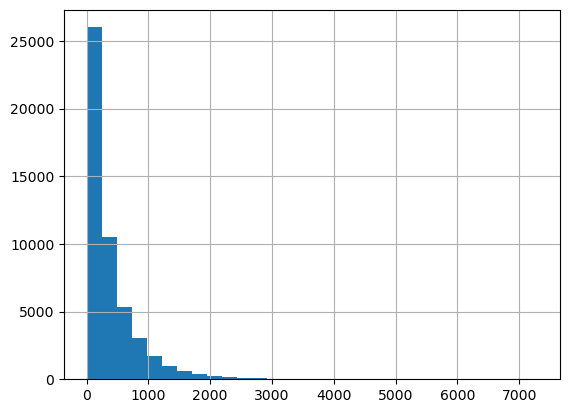

In [374]:
df['Total_Spending'].hist(bins=30)

In [375]:
df['Total_Spending'].skew()

np.float64(2.980876976829427)

In [376]:
df['Total_Spending_Log'] = np.log1p(df['Total_Spending'])

In [377]:
df['Total_Spending_Log'].skew()

np.float64(-1.4990450214910653)

<Axes: >

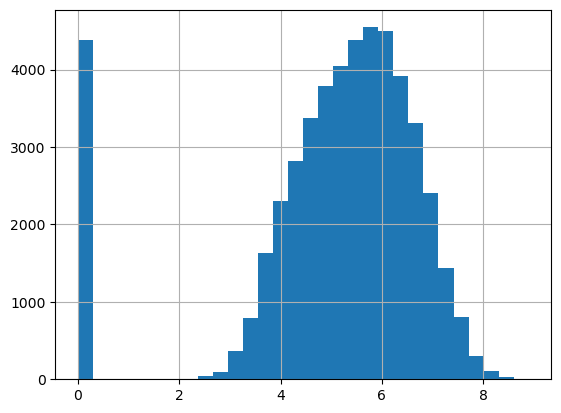

In [378]:
df['Total_Spending_Log'].hist(bins=30)

<Axes: xlabel='Total_Spending_Log'>

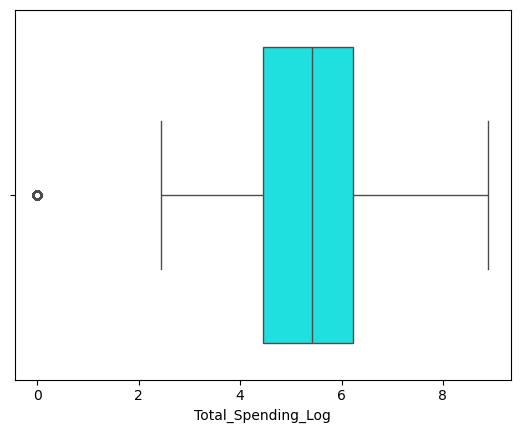

In [379]:
sns.boxplot(x=df['Total_Spending_Log'], color='cyan')

In [380]:
#Removing Outlier
Q1  = df['Total_Spending_Log'].quantile(0.25)
Q3  = df['Total_Spending_Log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Total_Spending_Log'] >= lower_bound) & (df['Total_Spending_Log'] <= upper_bound)]

<Axes: xlabel='Total_Spending_Log'>

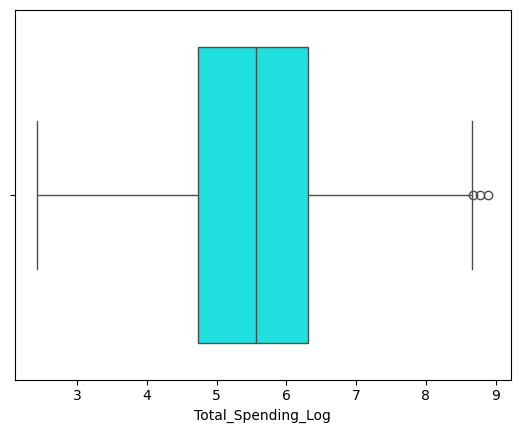

In [381]:
sns.boxplot(x=df['Total_Spending_Log'], color='cyan')

In [382]:
df['Spending_Segment'] = pd.qcut(
    df['Total_Spending'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'VIP'
    ]
)

In [383]:
df['Spending_Segment'].value_counts()

Spending_Segment
Low       11256
Medium    11256
High      11256
VIP       11256
Name: count, dtype: int64

In [384]:
df.groupby('Spending_Segment')['Purchase_Frequency'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2892701248.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Spending_Segment')['Purchase_Frequency'].mean()


Spending_Segment
Low        1.632463
Medium     3.827114
High       6.983387
VIP       12.050906
Name: Purchase_Frequency, dtype: float64

In [385]:
df.groupby('Spending_Segment')['Website_Visits'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\392711401.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Spending_Segment')['Website_Visits'].mean()


Spending_Segment
Low       18.659915
Medium    29.949094
High      46.277452
VIP       65.732054
Name: Website_Visits, dtype: float64

In [386]:
df.groupby('Spending_Segment')['Email_Open_Rate'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\3223618976.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Spending_Segment')['Email_Open_Rate'].mean()


Spending_Segment
Low       22.718181
Medium    29.395159
High      38.211706
VIP       47.048814
Name: Email_Open_Rate, dtype: float64

In [387]:
df.groupby('Spending_Segment')['Customer_Support_Tickets'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\3086510858.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Spending_Segment')['Customer_Support_Tickets'].mean()


Spending_Segment
Low       2.157161
Medium    1.928838
High      1.526119
VIP       1.155117
Name: Customer_Support_Tickets, dtype: float64

In [388]:
df.groupby('Spending_Segment')['Customer_Support_Tickets'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\3086510858.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Spending_Segment')['Customer_Support_Tickets'].mean()


Spending_Segment
Low       2.157161
Medium    1.928838
High      1.526119
VIP       1.155117
Name: Customer_Support_Tickets, dtype: float64

In [389]:
df.groupby('Spending_Segment')['Days_Since_Last_Purchase'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\398144311.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Spending_Segment')['Days_Since_Last_Purchase'].mean()


Spending_Segment
Low       116.054726
Medium     89.592751
High       56.959311
VIP        37.054993
Name: Days_Since_Last_Purchase, dtype: float64

In [390]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Registration_Date',
       'Last_Purchase_Date', 'Purchase_Frequency', 'Total_Spending',
       'Average_Order_Value', 'Website_Visits', 'Email_Open_Rate',
       'Customer_Support_Tickets', 'Age_Group', 'Customer_Tenure_Days',
       'Never_Purchased', 'Days_Since_Last_Purchase', 'Purchase_Recency_Group',
       'Purchase_Segment', 'Total_Spending_Log', 'Spending_Segment'],
      dtype='object')

### ***Average Order Value***

In [391]:
df['Average_Order_Value']

34286    94.17
39793    52.82
6670     38.74
10451    77.81
46709    32.14
         ...  
30366    34.75
2886     83.91
31988    62.23
44117    48.68
3586     82.73
Name: Average_Order_Value, Length: 45024, dtype: float64

In [392]:
df['Average_Order_Value'].isnull().sum()

np.int64(0)

In [393]:
df['Average_Order_Value'].describe()

count    45024.000000
mean        67.288146
std         39.294678
min         12.000000
25%         40.070000
50%         58.070000
75%         83.932500
max        420.000000
Name: Average_Order_Value, dtype: float64

np.float64(1.8383957679482021)

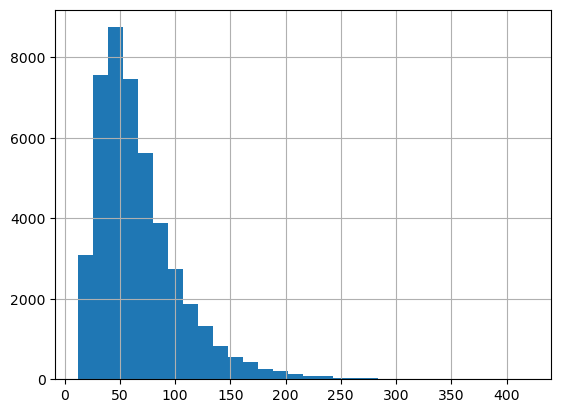

In [394]:
df['Average_Order_Value'].hist(bins=30)

df['Average_Order_Value'].skew()

<Axes: xlabel='Average_Order_Value'>

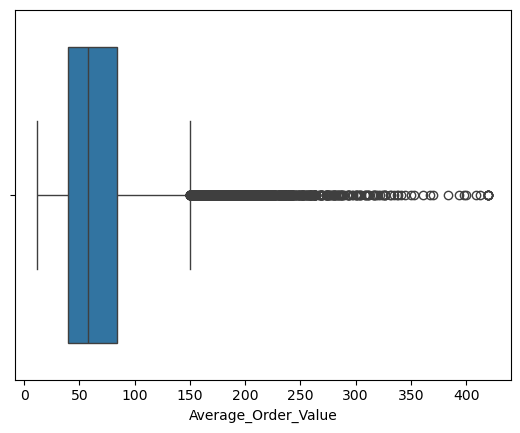

In [395]:
sns.boxplot(x=df['Average_Order_Value'])

In [396]:
df['Average_Order_Value'].nunique()

13106

In [397]:
Q1 = df['Average_Order_Value'].quantile(0.25)

Q3 = df['Average_Order_Value'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

In [398]:
#for modeling 
df['Average_Order_Value_Log'] = np.log1p(df['Average_Order_Value'])

In [399]:
df['AOV_Segment'] = pd.qcut(
    df['Average_Order_Value'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Premium'
    ]
)

In [400]:
df['AOV_Segment'].value_counts()

AOV_Segment
Low        11259
Medium     11257
Premium    11256
High       11252
Name: count, dtype: int64

<Axes: xlabel='Average_Order_Value_Log', ylabel='Count'>

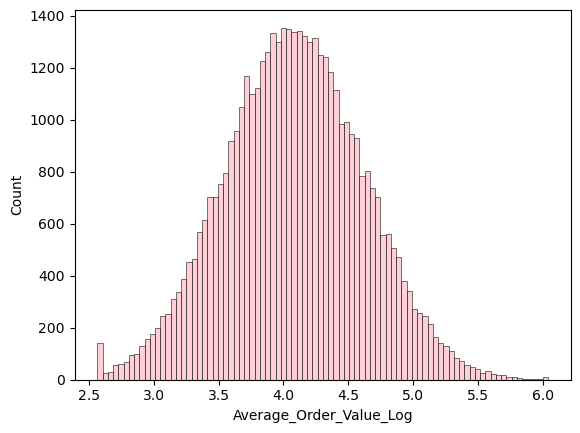

In [401]:
sns.histplot(x=df['Average_Order_Value_Log'], color='pink')

In [402]:
df.groupby('AOV_Segment')['Purchase_Frequency'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\3638039038.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AOV_Segment')['Purchase_Frequency'].mean()


AOV_Segment
Low        6.106759
Medium     6.042285
High       6.199342
Premium    6.145522
Name: Purchase_Frequency, dtype: float64

In [403]:
df.groupby('AOV_Segment')['Website_Visits'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\1855460923.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AOV_Segment')['Website_Visits'].mean()


AOV_Segment
Low        40.104272
Medium     39.875455
High       40.149573
Premium    40.489250
Name: Website_Visits, dtype: float64

In [404]:
df.groupby('AOV_Segment')['Email_Open_Rate'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2067036118.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AOV_Segment')['Email_Open_Rate'].mean()


AOV_Segment
Low        34.347468
Medium     34.609650
High       34.436487
Premium    34.267127
Name: Email_Open_Rate, dtype: float64

In [405]:
df.groupby('AOV_Segment')['Customer_Support_Tickets'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2879831780.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AOV_Segment')['Customer_Support_Tickets'].mean()


AOV_Segment
Low        1.714806
Medium     1.686595
High       1.693832
Premium    1.671997
Name: Customer_Support_Tickets, dtype: float64

In [406]:
df.groupby('AOV_Segment')['Days_Since_Last_Purchase'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2181800405.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AOV_Segment')['Days_Since_Last_Purchase'].mean()


AOV_Segment
Low        75.521094
Medium     74.432353
High       75.440899
Premium    74.267502
Name: Days_Since_Last_Purchase, dtype: float64

***Average Order Value (AOV) – Findings & Conclusion***

The analysis shows **very small differences** across all AOV segments in terms of purchase frequency, email engagement, customer support interactions, and days since the last purchase. This suggests that **Average Order Value alone is not a strong indicator of customer churn**. However, it still provides useful information about customer value and will be retained as a **supporting feature** in the model.

 ***Business Question Answer***

**Do customers with lower average order values show a higher risk of stopping purchases?**

**No, not significantly.** Customers across all AOV segments exhibit very similar purchasing and engagement behaviors, indicating that average order value by itself is not a strong predictor of churn. It may still help improve the model when combined with behavioral features such as purchase recency, purchase frequency, and website engagement.

### ***Websites Vists Column***

In [407]:
df['Website_Visits']

34286     20
39793      8
6670       0
10451      8
46709      4
        ... 
30366      0
2886      99
31988     37
44117    114
3586      41
Name: Website_Visits, Length: 45024, dtype: int64

In [408]:
df['Website_Visits'].describe()

count    45024.000000
mean        40.154629
std         32.876341
min          0.000000
25%         14.000000
50%         32.000000
75%         60.000000
max        193.000000
Name: Website_Visits, dtype: float64

In [409]:
df['Website_Visits'].isnull().sum()

np.int64(0)

<Axes: >

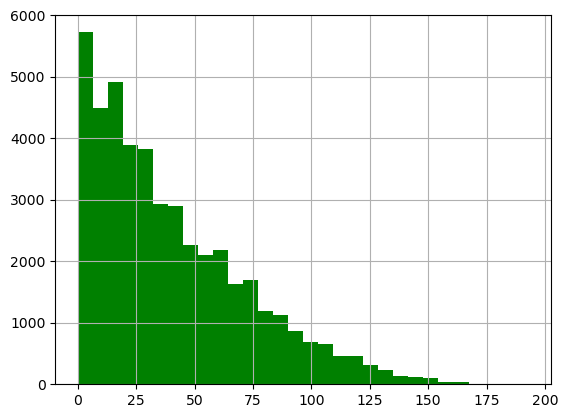

In [410]:
df['Website_Visits'].hist(bins=30, color='green')

In [411]:
df['Website_Visits'].skew()

np.float64(0.9939461585319977)

<Axes: xlabel='Website_Visits'>

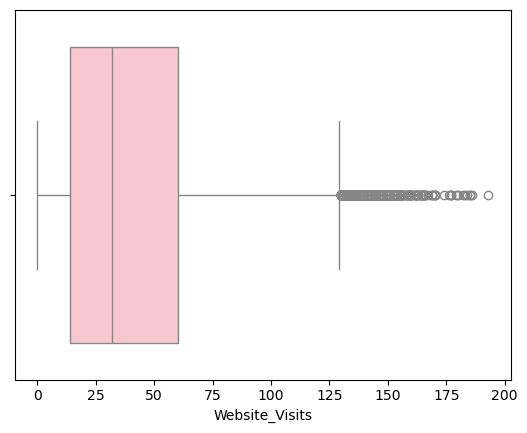

In [412]:
sns.boxplot(x=df['Website_Visits'], color='pink')

In [413]:
df['Website_Engagement'] = pd.qcut(
    df['Website_Visits'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [414]:
df['Website_Engagement'].value_counts()

Website_Engagement
Low          11698
High         11182
Medium       11143
Very High    11001
Name: count, dtype: int64

In [415]:
df.groupby('Website_Engagement')['Purchase_Frequency'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2892101777.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Website_Engagement')['Purchase_Frequency'].mean()


Website_Engagement
Low           2.689947
Medium        4.006731
High          6.930692
Very High    11.098082
Name: Purchase_Frequency, dtype: float64

In [416]:
df.groupby('Website_Engagement')['Total_Spending'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2798469296.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Website_Engagement')['Total_Spending'].mean()


Website_Engagement
Low          182.779863
Medium       275.369264
High         474.854871
Very High    756.948946
Name: Total_Spending, dtype: float64

In [417]:
df.groupby('Website_Engagement')['Email_Open_Rate'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\1626067305.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Website_Engagement')['Email_Open_Rate'].mean()


Website_Engagement
Low          21.480227
Medium       28.597119
High         38.421900
Very High    49.510119
Name: Email_Open_Rate, dtype: float64

In [418]:
df.groupby('Website_Engagement')['Customer_Support_Tickets'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\1841774893.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Website_Engagement')['Customer_Support_Tickets'].mean()


Website_Engagement
Low          2.335100
Medium       1.845464
High         1.475317
Very High    1.072175
Name: Customer_Support_Tickets, dtype: float64

In [419]:
df.groupby('Website_Engagement')['Days_Since_Last_Purchase'].mean()

C:\Users\AK\AppData\Local\Temp\ipykernel_14320\1997127189.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Website_Engagement')['Days_Since_Last_Purchase'].mean()


Website_Engagement
Low          128.482134
Medium        84.894463
High          50.318011
Very High     32.849196
Name: Days_Since_Last_Purchase, dtype: float64

***Website Visits – Findings & Conclusion***

The analysis shows a **strong relationship between website activity and customer engagement**. Customers with **Very High** website visits purchase more frequently, spend significantly more, open more emails, and have more recent purchases compared to customers with **Low** website activity. Additionally, customers with low website engagement generate more support tickets and have gone much longer without making a purchase. Therefore, `Website_Visits` appears to be **one of the strongest indicators of customer churn** and will be retained as a key feature in the prediction model.

***Business Question Answer***

**Do customers who visit the website less frequently show a higher risk of stopping purchases?**

**Yes.** Customers with lower website activity are substantially less engaged, spend less, and have much longer gaps since their last purchase. This suggests that declining website visits can act as an early warning sign for customers who are at risk of leaving.

### ***Email Open Rate***

In [420]:
df['Email_Open_Rate']

34286    20.05
39793    12.29
6670      0.00
10451     0.00
46709     1.72
         ...  
30366    44.45
2886     86.59
31988    47.96
44117    47.54
3586       NaN
Name: Email_Open_Rate, Length: 45024, dtype: float64

In [421]:
df['Email_Open_Rate'].isnull().sum()

np.int64(3994)

In [422]:
(df['Email_Open_Rate'].isnull().sum() / len(df)) * 100

np.float64(8.870824449182658)

In [423]:
df['Email_Open_Rate'].describe()

count    41030.000000
mean        34.415306
std         21.982673
min          0.000000
25%         17.060000
50%         33.080000
75%         49.827500
max         98.000000
Name: Email_Open_Rate, dtype: float64

<Axes: xlabel='Email_Open_Rate', ylabel='Count'>

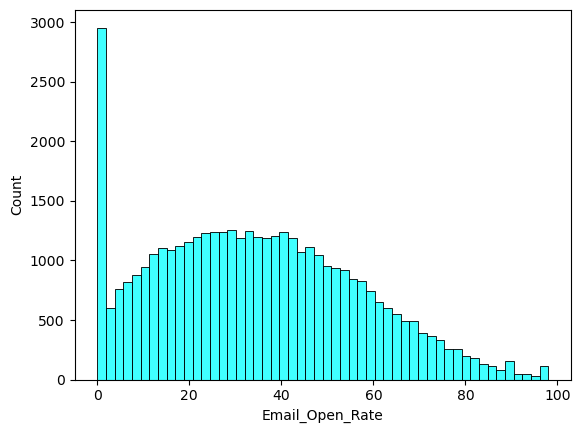

In [424]:
sns.histplot(x=df['Email_Open_Rate'], color='cyan')

In [425]:
df['Email_Open_Rate_Missing'] = (
    df['Email_Open_Rate']
    .isnull()
    .astype(int)
)

In [426]:
df['Email_Open_Rate_Missing']

34286    0
39793    0
6670     0
10451    0
46709    0
        ..
30366    0
2886     0
31988    0
44117    0
3586     1
Name: Email_Open_Rate_Missing, Length: 45024, dtype: int64

In [427]:
df['Email_Open_Rate'] = (
    df['Email_Open_Rate']
    .fillna(df['Email_Open_Rate'].median())
)

In [428]:
df['Email_Open_Rate'].isnull().sum()

np.int64(0)

<Axes: xlabel='Email_Open_Rate'>

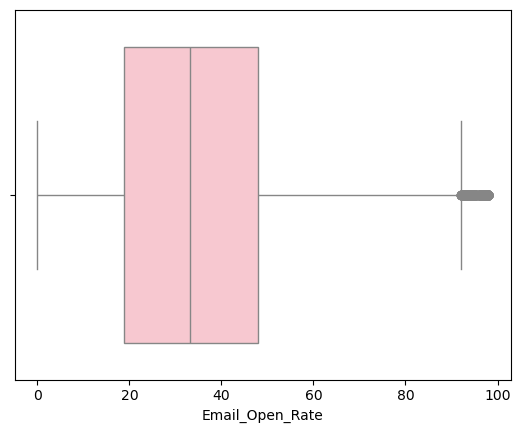

In [429]:
sns.boxplot(x=df['Email_Open_Rate'], color='pink')  

In [430]:
df['Email_Engagement'] = pd.qcut(
    df['Email_Open_Rate'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [431]:
df['Email_Engagement'].value_counts()

Email_Engagement
Medium       13253
Low          11257
Very High    11255
High          9259
Name: count, dtype: int64

In [432]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Registration_Date',
       'Last_Purchase_Date', 'Purchase_Frequency', 'Total_Spending',
       'Average_Order_Value', 'Website_Visits', 'Email_Open_Rate',
       'Customer_Support_Tickets', 'Age_Group', 'Customer_Tenure_Days',
       'Never_Purchased', 'Days_Since_Last_Purchase', 'Purchase_Recency_Group',
       'Purchase_Segment', 'Total_Spending_Log', 'Spending_Segment',
       'Average_Order_Value_Log', 'AOV_Segment', 'Website_Engagement',
       'Email_Open_Rate_Missing', 'Email_Engagement'],
      dtype='object')

### ***Customer Support Ticket Columns***

In [433]:
df['Customer_Support_Tickets']

34286    5
39793    3
6670     3
10451    3
46709    8
        ..
30366    1
2886     1
31988    0
44117    2
3586     0
Name: Customer_Support_Tickets, Length: 45024, dtype: int64

In [434]:
df['Customer_Support_Tickets'].isnull().sum()

np.int64(0)

In [435]:
df['Customer_Support_Tickets'].describe()

count    45024.000000
mean         1.691809
std          1.707126
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         13.000000
Name: Customer_Support_Tickets, dtype: float64

<Axes: >

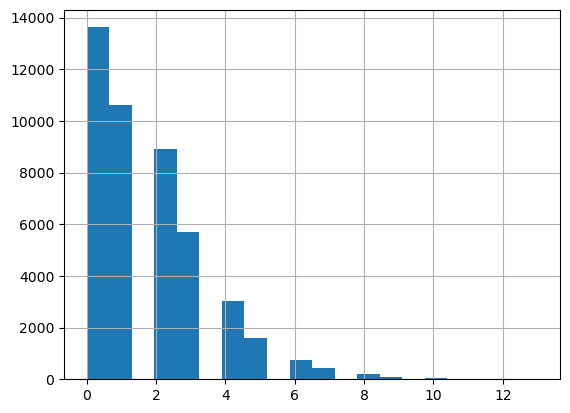

In [436]:
df['Customer_Support_Tickets'].hist(bins=20)

In [437]:
df['Customer_Support_Tickets'].skew()


np.float64(1.2701191511776988)

<Axes: xlabel='Customer_Support_Tickets'>

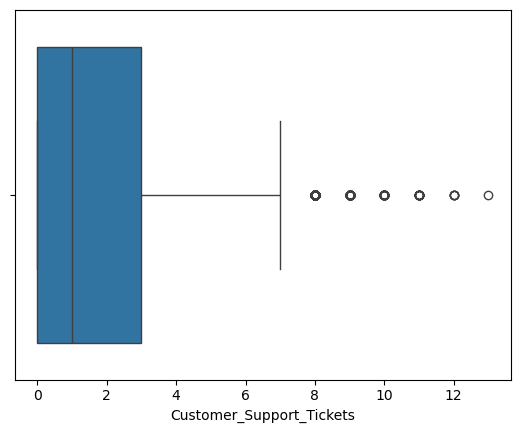

In [438]:
sns.boxplot(x=df['Customer_Support_Tickets'])

In [439]:
df['Support_Level'] = pd.cut(
    df['Customer_Support_Tickets'],
    bins=[-1,1,3,100],
    labels=[
        'Low',
        'Medium',
        'High'
    ]
)

In [440]:
df['Support_Level'].value_counts()

Support_Level
Low       24244
Medium    14615
High       6165
Name: count, dtype: int64

In [441]:
df.groupby('Support_Level')['Purchase_Frequency'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\789819482.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Support_Level')['Purchase_Frequency'].mean()


Support_Level
Low       7.051477
Medium    5.859391
High      3.100081
Name: Purchase_Frequency, dtype: float64

In [442]:
df.groupby('Support_Level')['Website_Visits'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2294025156.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Support_Level')['Website_Visits'].mean()


Support_Level
Low       46.204050
Medium    38.754978
High      19.683212
Name: Website_Visits, dtype: float64

In [443]:
df.groupby('Support_Level')['Total_Spending'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\1536277385.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Support_Level')['Total_Spending'].mean()


Support_Level
Low       482.114263
Medium    401.032863
High      209.918506
Name: Total_Spending, dtype: float64

In [444]:
df.groupby('Support_Level')['Email_Open_Rate'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\106231387.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Support_Level')['Email_Open_Rate'].mean()


Support_Level
Low       37.255273
Medium    33.711967
High      24.049359
Name: Email_Open_Rate, dtype: float64

In [445]:
df.groupby('Support_Level')['Days_Since_Last_Purchase'].mean()


C:\Users\AK\AppData\Local\Temp\ipykernel_14320\2479632701.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Support_Level')['Days_Since_Last_Purchase'].mean()


Support_Level
Low        62.037205
Medium     74.330346
High      126.946472
Name: Days_Since_Last_Purchase, dtype: float64

In [446]:
cols = [
'Age',
'Customer_Tenure_Days',
'Days_Since_Last_Purchase',
'Purchase_Frequency',
'Total_Spending',
'Average_Order_Value',
'Website_Visits',
'Email_Open_Rate',
'Customer_Support_Tickets'
]

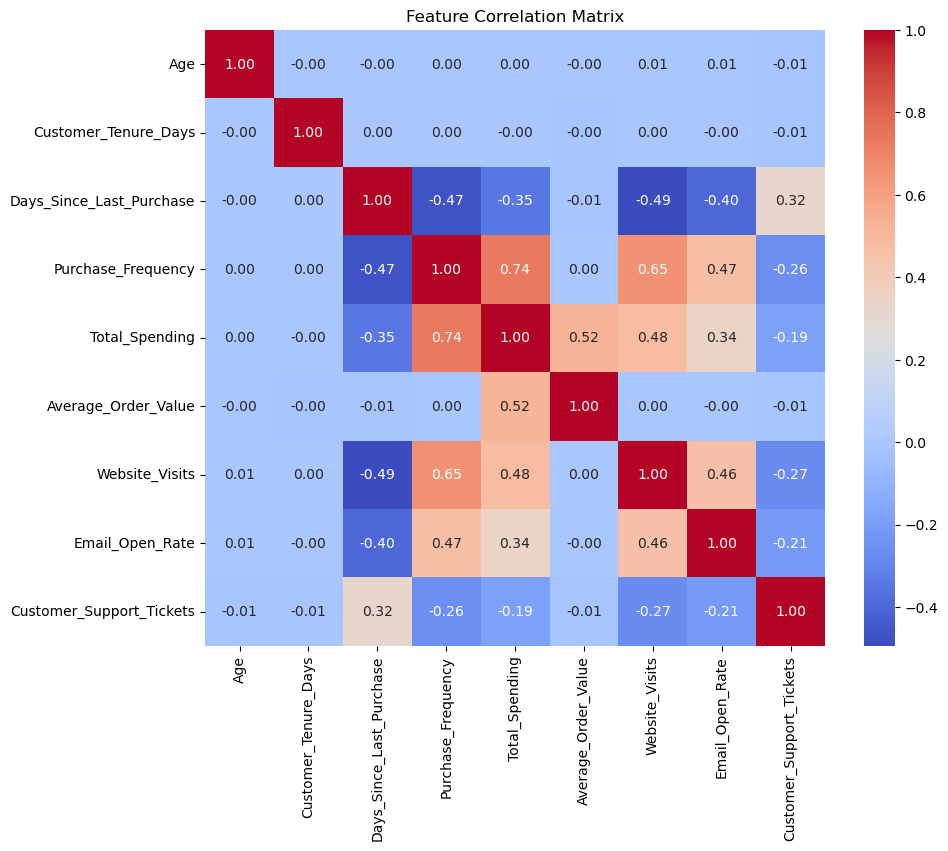

In [447]:
corr = df[cols].corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Matrix')
plt.show()

### **Defining The Target Variable**


In [448]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Registration_Date',
       'Last_Purchase_Date', 'Purchase_Frequency', 'Total_Spending',
       'Average_Order_Value', 'Website_Visits', 'Email_Open_Rate',
       'Customer_Support_Tickets', 'Age_Group', 'Customer_Tenure_Days',
       'Never_Purchased', 'Days_Since_Last_Purchase', 'Purchase_Recency_Group',
       'Purchase_Segment', 'Total_Spending_Log', 'Spending_Segment',
       'Average_Order_Value_Log', 'AOV_Segment', 'Website_Engagement',
       'Email_Open_Rate_Missing', 'Email_Engagement', 'Support_Level'],
      dtype='object')

In [449]:
df['Days_Since_Last_Purchase'] >= 90

34286     True
39793     True
6670      True
10451     True
46709     True
         ...  
30366    False
2886     False
31988    False
44117    False
3586     False
Name: Days_Since_Last_Purchase, Length: 45024, dtype: bool

In [450]:
df['Churn'] = (
    df['Days_Since_Last_Purchase'] >= 90
).astype(int)

In [451]:
df['Churn'].nunique()

2

In [452]:
df['Churn'].value_counts()

Churn
0    30166
1    14858
Name: count, dtype: int64

0 → Active Customer

1 → At Risk Customer

In [453]:
df['Churn'].value_counts(normalize=True)*100

Churn
0    66.999822
1    33.000178
Name: proportion, dtype: float64

#### **Feature Selection**

including (age , gender, location , pruchase frequecy,AOV,Website vists,email open rate,days since last purchase,total_spending log,customer support tickets)

In [503]:
# 1. Drop columns
drop_cols = [
    'Customer_ID', 'Name', 'Registration_Date', 'Last_Purchase_Date',
    'Age_Group', 'Never_Purchased', 'Purchase_Recency_Group',
    'Purchase_Segment', 'Spending_Segment', 'AOV_Segment',
    'Website_Engagement', 'Email_Engagement', 'Support_Level',
    'Days_Since_Last_Purchase'
]

df_model = df.drop(columns=drop_cols, errors='ignore')

# 2. X and y
y = df_model['Churn']
X = df_model.drop('Churn', axis=1)

# 3. Recreate column lists AFTER dropping
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Age', 'Purchase_Frequency', 'Average_Order_Value', 'Website_Visits', 'Email_Open_Rate', 'Customer_Support_Tickets', 'Customer_Tenure_Days', 'Total_Spending_Log', 'Average_Order_Value_Log', 'Email_Open_Rate_Missing']
Categorical: ['Gender', 'Location']


In [504]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [505]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [506]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

models = {

    'Logistic Regression':
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Decision Tree':
    DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest':
    RandomForestClassifier(
        random_state=42
    ),

    'Gradient Boosting':
    GradientBoostingClassifier(
        random_state=42
    ),

    'KNN':
    KNeighborsClassifier()
}

In [507]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, clf in models.items():

    model = Pipeline([
        ('preprocessor', preprocessor),

        ('classifier', clf)
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(
        X_test
    )[:,1]

    results.append({

        'Model':name,

        'Accuracy':accuracy_score(
            y_test,
            y_pred
        ),

        'Precision':precision_score(
            y_test,
            y_pred
        ),

        'Recall':recall_score(
            y_test,
            y_pred
        ),

        'F1 Score':f1_score(
            y_test,
            y_pred
        ),

        'ROC AUC':roc_auc_score(
            y_test,
            y_prob
        )

    })

In [508]:
results_df = pd.DataFrame(results)

In [509]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.767574,0.659760,0.610700,0.634283,0.830798
1,Decision Tree,0.690949,0.530973,0.545087,0.537938,0.653946
2,Random Forest,0.767796,0.665539,0.595895,0.628795,0.826483
3,Gradient Boosting,0.775902,0.667840,0.638627,0.652907,0.836628
4,KNN,0.734592,0.604827,0.564939,0.584203,0.768440


In [510]:
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Purchase_Frequency',
                                                   'Average_Order_Value',
                                                   'Website_Visits',
                                                   'Email_Open_Rate',
                                                   'Customer_Support_Tickets',
                                                   'Customer_Tenure_Days',
                                                   'Total_Spending_Log',
                                                   'Average_Order_Value_Log',
                                                   'Email_Open_Rate_Missing']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Location'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [512]:
feature_names = best_model.named_steps[
    'preprocessor'
].get_feature_names_out()

importance = best_model.named_steps[
    'classifier'
].feature_importances_

importance_df = pd.DataFrame({

    'Feature': feature_names,

    'Importance': importance

})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
1,num__Purchase_Frequency,0.635617
3,num__Website_Visits,0.244015
4,num__Email_Open_Rate,0.052769
5,num__Customer_Support_Tickets,0.048332
7,num__Total_Spending_Log,0.007844
6,num__Customer_Tenure_Days,0.002606
2,num__Average_Order_Value,0.002345
9,num__Email_Open_Rate_Missing,0.002313
8,num__Average_Order_Value_Log,0.002073
0,num__Age,0.001444


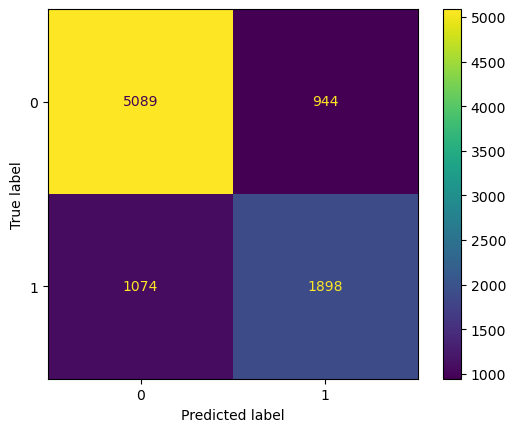

In [513]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

**Major finding**

Customers are most likely to churn when they:

- Purchase less frequently
- Visit the website less often
- Open fewer emails
- Create more support tickets

## Model Insights & Key Findings

The model identified `Purchase Frequency` and `Website Visits` as the two strongest drivers of customer churn, accounting for the majority of the predictive power. Customers who purchase less frequently and show reduced website activity are significantly more likely to stop purchasing.

Email engagement and customer support interactions also contribute to churn risk, although their impact is smaller. Features such as age and average order value have minimal influence on customer retention.

### Top Churn Indicators

1. Low Purchase Frequency
2. Low Website Visits
3. Low Email Open Rate
4. High Customer Support Tickets

These insights can help prioritize customers for retention campaigns before they leave.

## Hyperparameter Tuning

In [515]:
import optuna
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

In [516]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "random_state": 42
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(**params))
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [517]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best F1 Score:", study.best_value)
print("Best Parameters:", study.best_params)

[I 2026-06-24 10:32:18,840] A new study created in memory with name: no-name-76b95b72-4567-40ac-b5ab-7713c2ed6e80
[I 2026-06-24 10:33:30,811] Trial 0 finished with value: 0.652981683417434 and parameters: {'n_estimators': 68, 'learning_rate': 0.0630247386369524, 'max_depth': 2, 'min_samples_split': 5, 'min_samples_leaf': 6, 'subsample': 0.6955642686880769}. Best is trial 0 with value: 0.652981683417434.
[I 2026-06-24 10:34:07,036] Trial 1 finished with value: 0.6566744625655434 and parameters: {'n_estimators': 73, 'learning_rate': 0.0972919885509465, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 8, 'subsample': 0.8998059509679164}. Best is trial 1 with value: 0.6566744625655434.
[I 2026-06-24 10:34:52,689] Trial 2 finished with value: 0.6456104190176465 and parameters: {'n_estimators': 92, 'learning_rate': 0.1928283357237393, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 7, 'subsample': 0.8386119367143435}. Best is trial 1 with value: 0.6566744625655434.
[I 

Best F1 Score: 0.6608518043181819
Best Parameters: {'n_estimators': 152, 'learning_rate': 0.02769129417677277, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 2, 'subsample': 0.7110875853270872}


In [518]:
best_params = {
    'n_estimators': 152,
    'learning_rate': 0.02769129417677277,
    'max_depth': 4,
    'min_samples_split': 4,
    'min_samples_leaf': 2,
    'subsample': 0.7110875853270872,
    'random_state': 42
}

best_model = Pipeline([
    ('preprocessor', preprocessor),

    ('classifier',
     GradientBoostingClassifier(**best_params))
])

best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Purchase_Frequency',
                                                   'Average_Order_Value',
                                                   'Website_Visits',
                                                   'Email_Open_Rate',
                                                   'Customer_Support_Tickets',
                                                   'Customer_Tenure_Days',
                                                   'Total_Spending_Log',
                                                   'Average_Order_Value_Log',
                                                   'Email...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Location'])])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.02769129417677277,
                                            max_depth=4, min_samples_leaf=2,
                                            min_samples_split=4,
                                            n_estimators=152, random_state=42,
                                            subsample=0.7110875853270872))])

In [519]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

final_results = pd.DataFrame({

'Metric':[

'Accuracy',

'Precision',

'Recall',

'F1 Score',

'ROC AUC'

],

'Value':[

accuracy_score(y_test,y_pred),

precision_score(y_test,y_pred),

recall_score(y_test,y_pred),

f1_score(y_test,y_pred),

roc_auc_score(y_test,y_prob)

]

})

final_results

,Metric,Value
0,Accuracy,0.774459
1,Precision,0.664683
2,Recall,0.638964
3,F1 Score,0.651570
4,ROC AUC,0.836599


In [520]:
comparison = pd.DataFrame({

'Metric':[
'Accuracy',
'Precision',
'Recall',
'F1 Score',
'ROC AUC'
],

'Before':[
0.7759,
0.6678,
0.6386,
0.6529,
0.8366
],

'After':[
accuracy_score(y_test,y_pred),
precision_score(y_test,y_pred),
recall_score(y_test,y_pred),
f1_score(y_test,y_pred),
roc_auc_score(y_test,y_prob)
]

})

comparison

,Metric,Before,After
0,Accuracy,0.7759,0.774459
1,Precision,0.6678,0.664683
2,Recall,0.6386,0.638964
3,F1 Score,0.6529,0.651570
4,ROC AUC,0.8366,0.836599


#### ***Create risk segments.***

In [521]:
probs = best_model.predict_proba(X_test)[:,1]

risk_df = X_test.copy()

risk_df['Churn_Probability'] = probs

In [522]:
risk_df['Risk_Level'] = pd.cut(
    risk_df['Churn_Probability'],
    bins=[0,0.3,0.6,1],
    labels=[
        'Low Risk',
        'Medium Risk',
        'High Risk'
    ]
)

risk_df.head()

,Age,Gender,Location,Purchase_Frequency,Average_Order_Value,Website_Visits,Email_Open_Rate,Customer_Support_Tickets,Customer_Tenure_Days,Total_Spending_Log,Average_Order_Value_Log,Email_Open_Rate_Missing,Churn_Probability,Risk_Level
25740,30,Male,lahore,1,65.42,0,33.66,0,414.0,4.079738,4.195998,0,0.468851,Medium Risk
18818,25,Male,dubai,7,68.29,20,27.98,3,532.0,6.073851,4.238301,0,0.150277,Low Risk
29864,42,Male,multan,8,211.20,55,27.81,2,468.0,7.280904,5.357529,0,0.102617,Low Risk
24644,22,Female,dubai,3,107.33,28,8.83,4,57.0,5.843689,4.685182,0,0.584650,Medium Risk
11207,28,Male,dubai,2,36.31,42,49.43,3,347.0,4.265914,3.619261,0,0.282384,Low Risk
